<a href="https://colab.research.google.com/github/AlphaSimpli/ML_project/blob/main/ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1** - Importation des **librairies**

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

## **2** - Chargement des **données**

In [2]:
# Charger depuis GitHub
url = "https://raw.githubusercontent.com/AlphaSimpli/ML_project/main/sms-spam-collection-dataset.csv"
df = pd.read_csv(url, encoding="latin-1")

# Vérifier les colonnes
print(df.columns)

# S'assurer que label est codé 0/1
if df['label'].dtype == object:
    df['label'] = df['label'].map({'ham':0, 'spam':1})

# Aperçu
print(df.shape)
print(df['label'].value_counts())
df.head()

Index(['label', 'message'], dtype='object')
(5661, 2)
label
0    4825
1     836
Name: count, dtype: int64


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# **3** - Exploration des données (EDA)

In [3]:
print(df.shape)
print(df['label'].value_counts())

(5661, 2)
label
0    4825
1     836
Name: count, dtype: int64


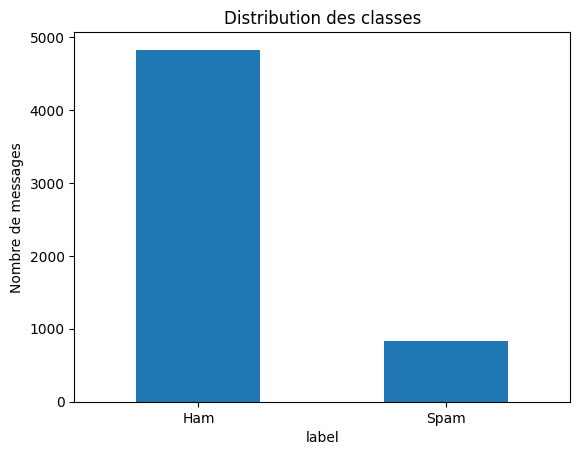

In [4]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Distribution des classes")
plt.xticks([0,1], ['Ham','Spam'], rotation=0)
plt.ylabel("Nombre de messages")
plt.show()

In [5]:
df['message_length'] = df['message'].apply(len)
df.head()

,label,message,message_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


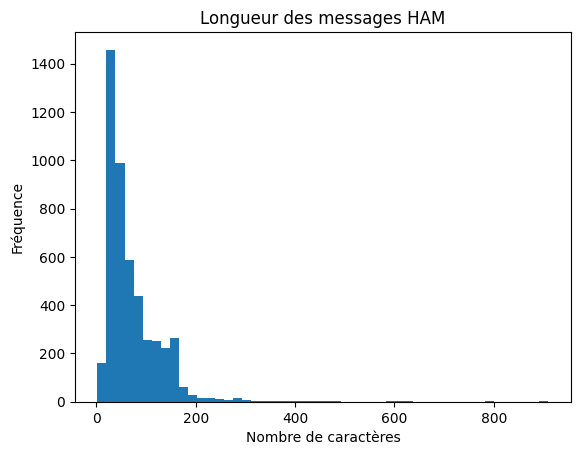

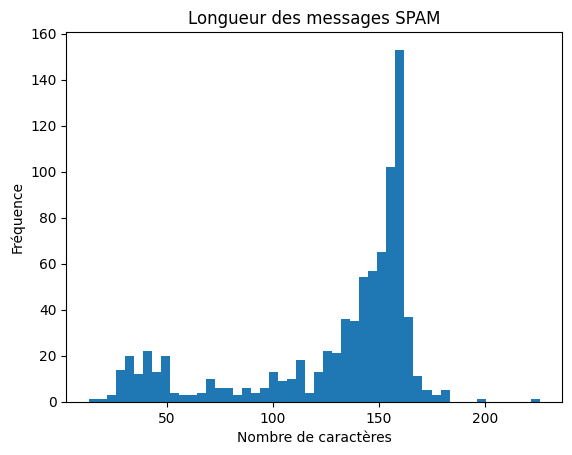

In [6]:
plt.hist(df[df['label']==0]['message_length'], bins=50)
plt.title("Longueur des messages HAM")
plt.xlabel("Nombre de caractères")
plt.ylabel("Fréquence")
plt.show()

plt.hist(df[df['label']==1]['message_length'], bins=50)
plt.title("Longueur des messages SPAM")
plt.xlabel("Nombre de caractères")
plt.ylabel("Fréquence")
plt.show()

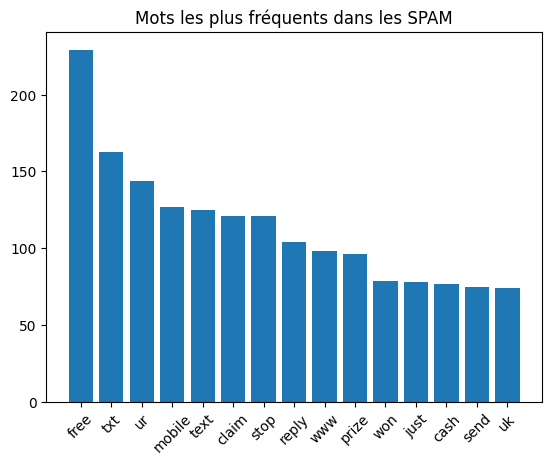

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

spam_words = df[df['label']==1]['message']
vectorizer_words = CountVectorizer(stop_words='english')
X_words = vectorizer_words.fit_transform(spam_words)

word_freq = np.asarray(X_words.sum(axis=0)).ravel()
words = vectorizer_words.get_feature_names_out()

freq_df = pd.DataFrame({'word': words, 'freq': word_freq})
top_words = freq_df.sort_values(by='freq', ascending=False).head(15)

plt.bar(top_words['word'], top_words['freq'])
plt.xticks(rotation=45)
plt.title("Mots les plus fréquents dans les SPAM")
plt.show()

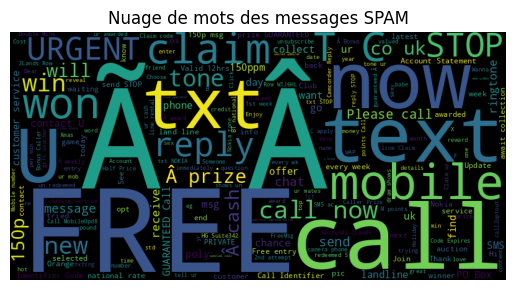

In [8]:
from wordcloud import WordCloud

spam_text = " ".join(df[df['label']==1]['message'])

wordcloud = WordCloud(width=800, height=400).generate(spam_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Nuage de mots des messages SPAM")
plt.show()

# **3) a** - Prétraitement du texte

In [9]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [10]:
def preprocess_text(text):

    # 1. minuscules
    text = text.lower()

    # 2. supprimer urls
    text = re.sub(r'http\S+', '', text)

    # 3. supprimer nombres
    text = re.sub(r'\d+', '', text)

    # 4. supprimer ponctuation
    text = re.sub(r'[^\w\s]', '', text)

    # 5. tokenisation (split mots)
    words = text.split()

    # 6. supprimer stopwords
    words = [w for w in words if w not in stop_words]

    # 7. stemming (win, winning → win)
    words = [stemmer.stem(w) for w in words]

    return " ".join(words)

In [11]:
df['clean_message'] = df['message'].apply(preprocess_text)
df[['message','clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


# **4** - Division Entraînement / Test

In [12]:
X = df['clean_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **5** - Texte vers Nombres (TF-IDF)

In [13]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(4528, 5000)


In [14]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train_tfidf, y_train)


In [15]:
nb_model = MultinomialNB()
lr_model = LogisticRegression(class_weight='balanced')
mlp_model = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=10)

nb_model.fit(X_resampled, y_resampled)
lr_model.fit(X_resampled, y_resampled)
mlp_model.fit(X_resampled, y_resampled)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=10)

# **6** - Fonction d'aide pour évaluer les modèles

In [16]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    print("-----", name, "-----")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

# **7** - Modèle 1 — Naive Bayes

In [17]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

evaluate_model(nb_model, X_test_tfidf, y_test, "Naive Bayes")

----- Naive Bayes -----
Accuracy : 0.9638128861429832
Precision: 0.991869918699187
Recall   : 0.7530864197530864
F1-score : 0.856140350877193

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       971
           1       0.99      0.75      0.86       162

    accuracy                           0.96      1133
   macro avg       0.98      0.88      0.92      1133
weighted avg       0.96      0.96      0.96      1133



# **8** - Modèle 2 — Régression Logistique

In [18]:
lr_model = LogisticRegression(class_weight='balanced')
lr_model.fit(X_train_tfidf, y_train)

evaluate_model(lr_model, X_test_tfidf, y_test, "Logistic Regression")

----- Logistic Regression -----
Accuracy : 0.9744042365401588
Precision: 0.8982035928143712
Recall   : 0.9259259259259259
F1-score : 0.9118541033434651

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       971
           1       0.90      0.93      0.91       162

    accuracy                           0.97      1133
   macro avg       0.94      0.95      0.95      1133
weighted avg       0.97      0.97      0.97      1133



# **9** - Modèle 3 — Réseau de neurones (MLP)

In [19]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

mlp_model = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=10)
mlp_model.fit(X_train_tfidf, y_train)

evaluate_model(mlp_model, X_test_tfidf, y_test, "Neural Network (MLP)")

----- Neural Network (MLP) -----
Accuracy : 0.9788172992056487
Precision: 0.9662162162162162
Recall   : 0.8827160493827161
F1-score : 0.9225806451612903

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       971
           1       0.97      0.88      0.92       162

    accuracy                           0.98      1133
   macro avg       0.97      0.94      0.96      1133
weighted avg       0.98      0.98      0.98      1133



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


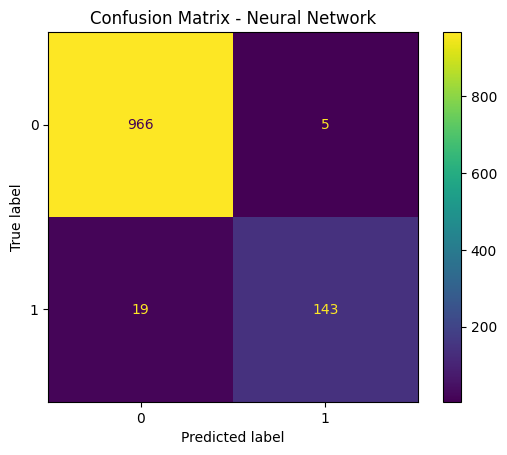

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = mlp_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Neural Network")
plt.show()

# **10** - Comparaison des résultats dans un tableau

In [21]:
models = {
    "Naive Bayes": nb_model,
    "Logistic Regression": lr_model,
    "Neural Network": mlp_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])
results_df

,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.963813,0.991870,0.753086,0.856140
1,Logistic Regression,0.974404,0.898204,0.925926,0.911854
2,Neural Network,0.978817,0.966216,0.882716,0.922581


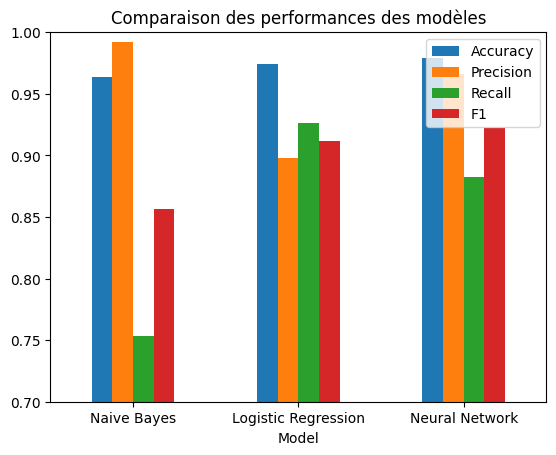

In [22]:
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1"]].plot(kind="bar")
plt.title("Comparaison des performances des modèles")
plt.xticks(rotation=0)
plt.ylim(0.7,1.0)
plt.show()

# **10) a** - PIPELINE + VALIDATION CROISÉE

In [23]:

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# X = TEXT RAW
X_text = df["message"]
y = df["label"]

# TF-IDF intégré dans pipeline
tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2)

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(128,64),
                                    max_iter=300,
                                    random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy','precision','recall','f1']

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("tfidf", tfidf),
        ("model", model)
    ])

    cv = cross_validate(
        pipeline,
        X_text, y,
        cv=skf,
        scoring=scoring
    )

    results.append([
        name,
        np.mean(cv['test_accuracy']),
        np.mean(cv['test_precision']),
        np.mean(cv['test_recall']),
        np.mean(cv['test_f1'])
    ])

cv_results_df = pd.DataFrame(results,
                             columns=["Model","Accuracy","Precision","Recall","F1"])

cv_results_df

,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.961137,0.998347,0.738031,0.848288
1,Logistic Regression,0.958841,0.984163,0.733248,0.840084
2,Neural Network,0.977035,0.948246,0.893520,0.919865


# **Test de prédiction**

In [24]:
def predict_spam(message, model):
    # Convert text → TF-IDF using the SAME vectorizer
    message_tfidf = vectorizer.transform([message])

    # Predict
    prediction = model.predict(message_tfidf)[0]

    if prediction == 1:
        return "🔴 SPAM"
    else:
        return "🟢 HAM (Not Spam)"

In [25]:
messages = [
    "Congratulations! You won a free iPhone. Click here now!",
    "Hey, are we still meeting tonight?",
    "URGENT! Your account has been suspended. Verify now!",
    "You have won $10,000 cash! Claim now."
]

models = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "Neural Network": mlp_model
}

for name, model in models.items():
    print(f"\n--- Model: {name} ---")

    # i starts at 0, so we use start=1 to make it human-readable
    for i, msg in enumerate(messages, start=1):
        result = predict_spam(msg, model)
        print(f" {i}. Message: \"{msg[:30]}...\" -> {result}")


--- Model: Logistic Regression ---
 1. Message: "Congratulations! You won a fre..." -> 🔴 SPAM
 2. Message: "Hey, are we still meeting toni..." -> 🟢 HAM (Not Spam)
 3. Message: "URGENT! Your account has been ..." -> 🔴 SPAM
 4. Message: "You have won $10,000 cash! Cla..." -> 🔴 SPAM

--- Model: Naive Bayes ---
 1. Message: "Congratulations! You won a fre..." -> 🔴 SPAM
 2. Message: "Hey, are we still meeting toni..." -> 🟢 HAM (Not Spam)
 3. Message: "URGENT! Your account has been ..." -> 🟢 HAM (Not Spam)
 4. Message: "You have won $10,000 cash! Cla..." -> 🔴 SPAM

--- Model: Neural Network ---
 1. Message: "Congratulations! You won a fre..." -> 🔴 SPAM
 2. Message: "Hey, are we still meeting toni..." -> 🟢 HAM (Not Spam)
 3. Message: "URGENT! Your account has been ..." -> 🔴 SPAM
 4. Message: "You have won $10,000 cash! Cla..." -> 🔴 SPAM
